# EDA - Indicateur 1 : qualité de vie

Ce notebook explore les fichiers silver de l'indicateur 1 sous l'angle "qualité de vie" : propreté, confort urbain, végétalisation, services publics et attractivité des espaces.

In [26]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

QOL_KEYWORDS = {
    'proprete': ['proprete', 'incident', 'degradation', 'sanisette', 'chantiers', 'graffiti'],
    'vegetalisation': ['arbre', 'ilots', 'fraicheur', 'espace_vert', 'espaces_verts'],
    'services': ['eclairage', 'touristique', 'zone', 'mobilite', 'equipement'],
}

def resolve_silver_dir() -> Path:
    current_dir = Path.cwd()
    candidates = [current_dir / 'silver', current_dir / 'Indicateur_1' / 'silver']
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Impossible de localiser le dossier silver de l\'indicateur 1.')

def find_columns(df: pd.DataFrame, keywords: list[str]) -> list[str]:
    lowered = {col: col.lower() for col in df.columns}
    return [col for col, low in lowered.items() if any(keyword in low for keyword in keywords)]

def missing_rate(df: pd.DataFrame) -> float:
    total = df.size
    return 0.0 if total == 0 else round(df.isna().sum().sum() / total * 100, 2)

def postal_code_series(df: pd.DataFrame) -> pd.Series:
    for candidate in ['cp_arrondissement', 'code_postal']:
        if candidate in df.columns:
            return df[candidate].astype(str).str.extract(r'(\d{5})', expand=False)

    if 'arrondissement' in df.columns:
        arr = df['arrondissement'].astype(str)
        extracted = arr.str.extract(r'(\d{1,2})', expand=False)
        return extracted.dropna().apply(lambda x: f'750{int(x):02d}')

    return pd.Series(dtype='object')

def plot_top_categories(df: pd.DataFrame, columns: list[str], title_prefix: str):
    available = [col for col in columns if col in df.columns]
    if not available:
        print(f'{title_prefix}: aucune colonne catégorielle disponible.')
        return

    fig, axes = plt.subplots(len(available), 1, figsize=(12, max(4, 3 * len(available))))
    if len(available) == 1:
        axes = [axes]

    for ax, col in zip(axes, available):
        top_values = df[col].astype(str).value_counts(dropna=False).head(10)
        top_values.plot(kind='bar', ax=ax, color='#457b9d')
        ax.set_title(f'{title_prefix} - top valeurs de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Fréquence')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def plot_postal_code_distribution(df: pd.DataFrame, title: str):
    postal_codes = postal_code_series(df).dropna()
    if postal_codes.empty:
        print(f'{title}: aucun code postal exploitable.')
        return

    counts = postal_codes.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    counts.plot(kind='bar', ax=ax, color='#2a9d8f')
    ax.set_title(title)
    ax.set_xlabel('Code postal')
    ax.set_ylabel('Nombre d\'occurrences')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [27]:
silver_dir = resolve_silver_dir()
parquet_files = sorted(silver_dir.glob('*.parquet'))
parquet_files

[WindowsPath('c:/Users/mrand/Documents/M1 DE/Data architecture projet/projet/docker-hadoop-spark-master/vrai_projet/luximmo/Indicateur_1/silver/chantiers.parquet'),
 WindowsPath('c:/Users/mrand/Documents/M1 DE/Data architecture projet/projet/docker-hadoop-spark-master/vrai_projet/luximmo/Indicateur_1/silver/dans_ma_rue.parquet'),
 WindowsPath('c:/Users/mrand/Documents/M1 DE/Data architecture projet/projet/docker-hadoop-spark-master/vrai_projet/luximmo/Indicateur_1/silver/eclairage-public.parquet'),
 WindowsPath('c:/Users/mrand/Documents/M1 DE/Data architecture projet/projet/docker-hadoop-spark-master/vrai_projet/luximmo/Indicateur_1/silver/ilots-de-fraicheur-equipements-activites.parquet'),
 WindowsPath('c:/Users/mrand/Documents/M1 DE/Data architecture projet/projet/docker-hadoop-spark-master/vrai_projet/luximmo/Indicateur_1/silver/ilots-de-fraicheur-espaces-verts-frais.parquet'),
 WindowsPath('c:/Users/mrand/Documents/M1 DE/Data architecture projet/projet/docker-hadoop-spark-master/vr

## Vue d'ensemble orientée qualité de vie
Le tableau suivant résume les volumes, la complétude et les colonnes potentiellement utiles pour lire les données sous l'angle propreté, végétalisation, confort urbain et services publics.

In [28]:
summary_rows = []
datasets = {}

for file_path in parquet_files:
    df = pd.read_parquet(file_path)
    datasets[file_path.stem] = df
    qol_columns = find_columns(df, ['arrondissement', 'quartier', 'type', 'categorie', 'nature', 'statut', 'etat', 'nom', 'code_postal', 'latitude', 'longitude', 'lon', 'lat', 'date'])
    summary_rows.append({
        'fichier': file_path.name,
        'lignes': len(df),
        'colonnes': df.shape[1],
        'colonnes_numeriques': df.select_dtypes(include='number').shape[1],
        'colonnes_texte': df.select_dtypes(include='object').shape[1],
        'colonnes_qol_detectees': len(qol_columns),
        'taux_valeurs_manquantes_pct': missing_rate(df)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('fichier').reset_index(drop=True)
summary_df

C:\Users\mrand\AppData\Local\Temp\ipykernel_22408\184037950.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'colonnes_texte': df.select_dtypes(include='object').shape[1],
C:\Users\mrand\AppData\Local\Temp\ipykernel_22408\184037950.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/use

,fichier,lignes,colonnes,colonnes_numeriques,colonnes_texte,colonnes_qol_detectees,taux_valeurs_manquantes_pct
0,chantiers.parquet,100,14,1,13,4,5.21
1,dans_ma_rue.parquet,100,17,3,14,6,0.00
2,eclairage-public.parquet,165629,70,0,70,6,22.75
3,ilots-de-fraicheur-equipements-activites.parquet,548,19,0,19,4,37.74
4,ilots-de-fraicheur-espaces-verts-frais.parquet,986,27,5,22,7,17.82
5,les-arbres.parquet,218055,16,3,13,2,11.09
6,sanisettesparis.parquet,617,10,0,10,3,7.37
7,zones-touristiques-internationales.parquet,12,12,0,12,1,0.00


## Aperçu des données
Pour chaque fichier silver, on affiche les 10 premières lignes afin de repérer rapidement les champs qui décrivent l'espace public, les équipements et les usages.

In [29]:
for name, df in datasets.items():
    qol_cols = find_columns(df, ['arrondissement', 'quartier', 'type', 'categorie', 'nature', 'statut', 'etat', 'nom', 'code_postal', 'latitude', 'longitude', 'lon', 'lat'])
    print(f'### {name}')
    print(f'Colonnes orientées qualité de vie détectées: {", ".join(qol_cols) if qol_cols else "aucune"}')
    display(df.head(10))
    print()

### chantiers
Colonnes orientées qualité de vie détectées: cp_arrondissement, chantier_categorie


,num_emprise,cp_arrondissement,date_debut,date_fin,chantier_categorie,moa_principal,surface,chantier_synthese,localisation_detail,localisation_stationnement,demande_cite_id,chantier_cite_id,geo_shape,geo_point_2d
0,EC500495,75008,2026-05-21,2026-05-22,Ville de Paris (Tvx sur espace ou édifice public),Ville de Paris (autres),247.90,Travaux sur édifice public (VdP*),['EMPRISE_CHAUSSEE'],NaN,949817,324501,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.324950667424672, 'lat': 48.870806882..."
1,EC369543,75001,2023-11-30,2026-12-31,Ville de Paris (Tvx sur espace ou édifice public),Section de l'Assainissement de Paris,99.19,Travaux sur réseau d’assainissement,"['EMPRISE_CHAUSSEE', 'EMPRISE_TROTTOIR']",NaN,848175,242276,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3431262002156426, 'lat': 48.85514609..."
2,EC397864,75015,2024-07-01,2026-08-31,Ville de Paris (Tvx sur espace ou édifice public),Ville de Paris (autres),116.90,Travaux sur édifice public (VdP*),['EMPRISE_TROTTOIR'],['STATIONNEMENT_PAYANT'],869470,259543,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3092680092650366, 'lat': 48.83668933..."
3,EC493309,75018,2026-04-27,2026-05-27,Ville de Paris (Tvx sur espace ou édifice public),Ville de Paris (autres),1.57,Travaux sur édifice public (VdP*),['EMPRISE_TROTTOIR'],NaN,943896,320833,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.354150415059239, 'lat': 48.884951835..."
4,EC495541,75016,2026-03-23,2026-05-29,Ville de Paris (Tvx sur espace ou édifice public),Ville de Paris (autres),2.12,Travaux sur édifice public (VdP*),['EMPRISE_TROTTOIR'],NaN,946975,322243,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.280328779023418, 'lat': 48.856631755..."
5,EC492879,75011,2026-04-13,2026-06-19,Ville de Paris (Tvx sur espace ou édifice public),Section de l'Assainissement de Paris,20.00,Travaux sur réseau d’assainissement,"['EMPRISE_CHAUSSEE', 'EMPRISE_TROTTOIR']",NaN,944990,320646,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.370237417948382, 'lat': 48.864488496..."
6,EC494273,75013,2026-05-11,2026-07-24,Ville de Paris (Tvx sur espace ou édifice public),Direction de la Voirie et des Déplacements,6557.36,Aménagement de voirie (VdP*),"['EMPRISE_CHAUSSEE', 'EMPRISE_TROTTOIR']",NaN,945985,321436,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.344631179034829, 'lat': 48.824282240..."
7,EC490102,75012,2026-02-23,2026-05-29,Ville de Paris (Tvx sur espace ou édifice public),Direction de la Voirie et des Déplacements,23.70,Aménagement ou entretien de l’espace public,['EMPRISE_CHAUSSEE'],NaN,943050,319061,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.401149440533947, 'lat': 48.842601660..."
8,EC469813,75014,2025-12-15,2028-08-31,Opérateurs de réseau (gaz-électricité-RATP-etc),RATP,357.06,Travaux sur réseau de transport public,['EMPRISE_TROTTOIR'],NaN,926506,305760,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.340438417093136, 'lat': 48.820094482..."
9,EC500079,75017,2026-05-04,2026-06-05,Ville de Paris (Tvx sur espace ou édifice public),Direction de la Voirie et des Déplacements,80.24,Aménagement ou entretien de l’espace public,['EMPRISE_CHAUSSEE'],NaN,950818,325278,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.319383614465819, 'lat': 48.884419800..."



### dans_ma_rue
Colonnes orientées qualité de vie détectées: type, soustype, code_postal, arrondissement, conseilquartier


,numero,type,soustype,adresse,code_postal,ville,arrondissement,conseilquartier,datedecl,anneedecl,moisdecl,prefixe,intervenant,id_dmr,geo_shape,geo_point_2d,mois_annee_decla
0,98815,"Graffitis, tags, affiches et autocollants","Graffitis et autocollants sur mur, façade sur ...","5 Rue de Clignancourt, 75018 PARIS",75018,Paris 18,18,MONTMARTRE,2025-11-20,2025,11,Android,graffitis,G2025K098815,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.346955299858789, 'lat': 48.884124998...",2025-11
1,85615,Propreté,Déchets et/ou salissures divers,"25 Rue Lantiez, 75017 PARIS",75017,Paris 17,17,LA FOURCHE - GUY MOQUET,2025-02-17,2025,2,Android,DPE-STPP-DT,G2025B085615,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3236635005742166, 'lat': 48.89500799...",2025-02
2,69973,"Autos, motos, vélos, trottinettes...",[] Deux-roues motorisé en stationnement gênant U2,"19 Rue Moncey, 75009 PARIS",75009,Paris 09,9,BLANCHE - TRINITE,2025-11-14,2025,11,IOS application,DPMP-Divisions,A2025K069973,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.329218100326577, 'lat': 48.879889999...",2025-11
3,120702,Voirie et espace public,Chantier : Chantier de voirie sans barrière ou...,"39 Rue du Faubourg Poissonnière, 75009 PARIS",75009,Paris 09,9,FAUBOURG MONTMARTRE,2025-12-22,2025,12,IOS application,DVD,A2025L120702,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.347831699532403, 'lat': 48.873725998...",2025-12
4,100794,Mobiliers urbains,"Protection : Potelet, barrière ou garde-corps ...","61 boulevard Saint-Marcel, 75005 PARIS",75005,Paris 13,13,SALPETRIERE - AUSTERLITZ,2026-01-20,2026,1,Android,SMEP,G2026A100794,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3548297998036016, 'lat': 48.83751999...",2026-01
5,143213,"Graffitis, tags, affiches et autocollants","Graffitis et autocollants sur mur, façade sur ...","167 Avenue Jean Jaurès, 75019 PARIS",75019,Paris 19,19,MANIN - JAURES,2025-02-27,2025,2,Android,graffitis,G2025B143213,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.387584699394134, 'lat': 48.887412998...",2025-02
6,67465,"Graffitis, tags, affiches et autocollants","Affiches, autocollants ou graffitis sur mobili...","106 Boulevard de Ménilmontant, 75020 PARIS",75020,Paris 20,20,AMANDIERS - MENILMONTANT,2025-01-14,2025,1,Android,graffitis,G2025A067465,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.3856058005415455, 'lat': 48.86502499...",2025-01
7,88860,Propreté,Déchets et/ou salissures divers,"15 Avenue de Choisy, 75013 PARIS",75013,Paris 13,13,OLYMPIADES - CHOISY,2025-05-18,2025,5,Android,DPE-STPP-DT,G2025E088860,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.363539499714865, 'lat': 48.820914998...",2025-05
8,2924,Propreté,Déchets et/ou salissures divers,"1 Boulevard Pershing, 75017 PARIS",75017,Paris 17,17,TERNES - MAILLOT,2025-02-01,2025,2,IOS application,DPE-STPP-DT,A2025B002924,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.2852181993251874, 'lat': 48.88160999...",2025-02
9,148940,Objets abandonnés,Autres objets encombrants abandonnés,"19 Rue du Château d'Eau, 75010 PARIS",75010,Paris 10,10,CHATEAU D'EAU - LANCRY,2025-04-28,2025,4,Android,DPE-STPP-DT,G2025D148940,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': 2.360172999367602, 'lat': 48.870025998...",2025-04



### eclairage-public
Colonnes orientées qualité de vie détectées: voie_nature, voie_categorie, arrondissement, support_type


...

,idbase,typeemplacement,domanialite,arrondissement,complementadresse,adresse,idemplacement,libellefrancais,genre,espece,varieteoucultivar,circonferenceencm,hauteurenm,stadedeveloppement,remarquable,geo_point_2d
0,126117,Arbre,Jardin,PARIS 20E ARRDT,NaN,JARDIN DE LA GARE DE CHARONNE / 59 BOULEVARD D...,000103036,Cèdre,Cedrus,atlantica,NaN,130,15,Adulte,NON,0101000000c1c1b164af46034054d53ba3fb6c4840
1,141306,Arbre,CIMETIERE,PARIS 15E ARRDT,NaN,CIMETIERE DE VAUGIRARD / AVENUE PRINCIPALE / D...,A14000011002,Erable,Acer,platanoides,NaN,75,8,Adulte,NON,0101000000500ff15bb6460240e5b5e0264e6b4840
2,250335,Arbre,Alignement,PARIS 19E ARRDT,NaN,RUE MANIN,001002013,Platane,Platanus,x hispanica,NaN,120,20,Adulte,NON,01010000008e2ba129911e0340119a54821e714840
3,278516,Arbre,Alignement,PARIS 13E ARRDT,NaN,BOULEVARD KELLERMANN,000202013,Marronnier,Aesculus,x carnea,''Briotii'',115,10,Adulte,NON,0101000000da33c2a1d1dc0240b53571e9e2684840
4,216594,Arbre,Alignement,PARIS 19E ARRDT,15,AVENUE DE LAUMIERE,000101011,Paulownia,Paulownia,tomentosa,NaN,60,8,Jeune (arbre),NON,0101000000cf0bb4ace70b0340edd0825f14714840
5,223855,Arbre,Alignement,PARIS 11E ARRDT,116,BOULEVARD RICHARD LENOIR,000704007,Platane,Platanus,x hispanica,NaN,30,6,Jeune (arbre),NON,0101000000cb3b104960f70240f25275d1a96e4840
6,106474,Arbre,Jardin,PARIS 7E ARRDT,Canton 10,JARDIN DU CHAMP DE MARS ET PELOUSES DE L ECOLE...,A01002004,Platane,Platanus,x hispanica,NaN,95,12,Adulte,NON,01010000001a8ccedfd066024062e7e94b556d4840
7,266201,Arbre,Alignement,PARIS 15E ARRDT,111,BOULEVARD LEFEBVRE,000701006,Platane,Platanus,x hispanica,NaN,110,15,Adulte,NON,0101000000f0ec64f379600240048b5b19306a4840
8,157556,Arbre,CIMETIERE,VAL-DE-MARNE,NaN,CIMETIERE DE THIAIS / AVENUE I / DIV 91,A12100091008,Frêne à fleurs,Fraxinus,ornus,NaN,20,5,NaN,NON,0101000000a676c7831b0003403322a33dde604840
9,105989,Arbre,Jardin,PARIS 20E ARRDT,NaN,SQUARE SEVERINE / 1 RUE LE VAU,000202022,Sequoia,Sequoiadendron,giganteum,NaN,215,15,Adulte,NON,0101000000a78674f5ce450340087ddff5c06e4840



### sanisettesparis
Colonnes orientées qualité de vie détectées: type, statut, arrondissement


,type,statut,adresse,arrondissement,horaire,acces_pmr,relais_bebe,url_fiche_equipement,geo_shape,geo_point_2d
0,WC,Hors service,2 quai de l archeveche,75004,Horaires du parc,Non,Non,https://www.paris.fr/lieux/square-jean-xxiii-35,01010000007b965ed0face0240ca13972a2a6d4840,01010000007b965ed0face0240ca13972a2a6d4840
1,Sanisette,En service,36 bd de sebastopol,75004,06h00 - 22h00,Oui,Non,NaN,0101000000768a9facdfcc0240950e5488476e4840,0101000000768a9facdfcc0240950e5488476e4840
2,Sanisette,En service,10 avenue de l observatoire,75006,Horaires du parc,Oui,Non,https://www.paris.fr/lieux/jardin-des-grands-e...,010100000070765eb5b5b20240fd96e4cfcd6b4840,010100000070765eb5b5b20240fd96e4cfcd6b4840
3,Sanisette,En service,93b bd du montparnasse,75006,06h00 - 22h00,Non,Non,NaN,01010000002022ead5e39e0240bcbb3f19e36b4840,01010000002022ead5e39e0240bcbb3f19e36b4840
4,Sanisette,En service,135b bd du montparnasse,75006,06h00 - 22h00,Oui,Non,NaN,0101000000630e2fa4a7a802403075d218ad6b4840,0101000000630e2fa4a7a802403075d218ad6b4840
5,Sanisette,En service,2t pl joffre,75007,24/24h,Oui,Non,NaN,01010000009279b3fcdc7002403ff3dcb75a6d4840,01010000009279b3fcdc7002403ff3dcb75a6d4840
6,Sanisette,En service,1 av de verdun,75010,24/24h,Oui,Non,NaN,010100000061ba8b4127e402409edb3e6f2a704840,010100000061ba8b4127e402409edb3e6f2a704840
7,Sanisette,En service,81b bd de la villette,75010,06h00 - 22h00,Oui,Non,NaN,0101000000c7ca33bd8bf7024064dcb4a84f704840,0101000000c7ca33bd8bf7024064dcb4a84f704840
8,Sanisette,En service,96 rue oberkampf,75011,06h00 - 22h00,Oui,Non,NaN,01010000009f4ef4f6590503403e81a741d16e4840,01010000009f4ef4f6590503403e81a741d16e4840
9,WC,En service,30 rue du rendez-vous,75012,Horaires du parc,Oui,Non,https://www.paris.fr/lieux/jardin-debergue-ren...,01010000002c3798ba353b034065625f765c6c4840,01010000002c3798ba353b034065625f765c6c4840



### zones-touristiques-internationales
Colonnes orientées qualité de vie détectées: type


,name,type,_timestamp,_uid,source,_user,_version,boundary,_changeset,_id,geo_point_2d,geo_shape
0,Saint-Honoré - Vendôme,boundary,2016-07-26T17:22:16Z,158826,JORFTEXT000031223603,cquest,1,tourist_zone,41043008,relation/6439132,01010000004a4d0c0c80a70240eee5fd8adc6e4840,0103000000010000006400000003f2800de3b90240fa2c...
1,Montmartre,boundary,2016-07-26T16:15:57Z,158826,JORFTEXT000031223591,cquest,1,tourist_zone,41041604,relation/6438767,0101000000ecf3384397b502409cbc521b5f714840,01030000000100000048000000113ae8120ead02409b59...
2,Olympiades,boundary,2016-07-26T16:39:02Z,158826,JORFTEXT000031223594,cquest,1,tourist_zone,41042071,relation/6439048,01010000009a9a3afb76e60240bc06e6f1a7694840,01030000000100000053000000b50aac2d86dc0240ee2b...
3,Le Marais,multipolygon,2016-07-26T15:30:19Z,158826,JORFTEXT000031223582,cquest,2,tourist_zone,41040695,relation/6438571,01010000003b4c88cb9de50240481d5827d26d4840,0103000000010000009000000066660badf3d402409d61...
4,Rennes - Saint-Sulpice,boundary,2016-07-26T17:30:29Z,158826,JORFTEXT000031223597,cquest,2,tourist_zone,41043224,relation/6439069,01010000008739798722a00240839afab1eb6c4840,0103000000010000004e000000bf64e3c1169b0240d4fe...
5,Maillot-Ternes,boundary,2016-07-26T15:53:40Z,158826,JORFTEXT000031223588,cquest,2,tourist_zone,41041163,relation/6438646,010100000073c1a906ed4e02404153fdea54704840,0106000000020000000103000000010000000800000016...
6,Saint-Germain,boundary,2016-07-26T17:30:29Z,158826,JORFTEXT000031223606,cquest,1,tourist_zone,41043224,relation/6439138,0101000000b16c797f6caa024026366daf966d4840,01030000000100000045000000bf64e3c1169b0240d4fe...
7,Haussmann,multipolygon,2016-07-26T17:22:16Z,158826,JORFTEXT000031223579,cquest,2,tourist_zone,41043008,relation/6438520,01010000000bebaee4fba80240b75487d7b36f4840,010300000001000000690000009553f135baa902408827...
8,Les Halles,boundary,2016-07-26T17:22:16Z,158826,JORFTEXT000031223585,cquest,2,tourist_zone,41043008,relation/6438629,010100000002fdf13d06ca02404a6a7c79356e4840,0103000000010000004200000052d32ea699be0240d3a0...
9,Champs-Elysées Montaigne,boundary,2016-07-26T14:10:50Z,158826,JORFTEXT000031223576,cquest,1,tourist_zone,41039106,relation/6438476,0101000000da0cd6a74e720240a69b0f8a506f4840,0103000000010000001e000000b1ec38341b6a0240ee56...


## Indicateurs utiles pour un score de qualité de vie
On regarde à la fois la taille des jeux de données et leur complétude, car un score de qualité de vie dépend autant du contenu métier que de la qualité de la couverture des données.

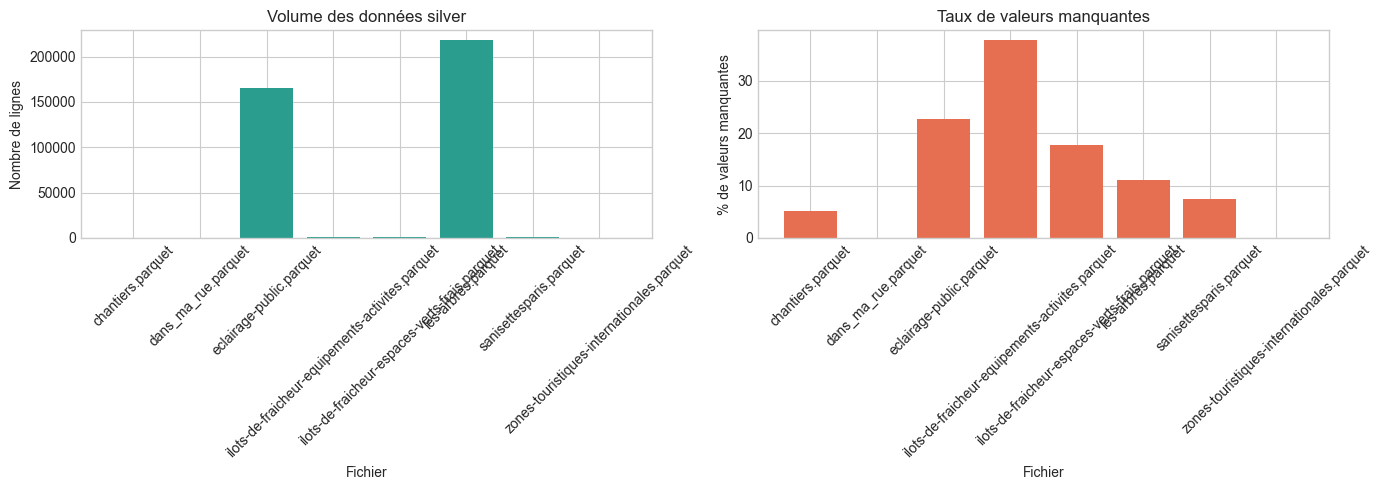

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df['fichier'], summary_df['lignes'], color='#2a9d8f')
axes[0].set_title('Volume des données silver')
axes[0].set_xlabel('Fichier')
axes[0].set_ylabel('Nombre de lignes')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(summary_df['fichier'], summary_df['taux_valeurs_manquantes_pct'], color='#e76f51')
axes[1].set_title('Taux de valeurs manquantes')
axes[1].set_xlabel('Fichier')
axes[1].set_ylabel('% de valeurs manquantes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Distributions métier pertinentes
On remplace les vues génériques par des visualisations plus utiles pour la qualité de vie : répartition par code postal pour les chantiers, les incidents et les arbres, puis un focus sur les zones touristiques internationales et les sanisettes.

### chantiers - distribution par code postal


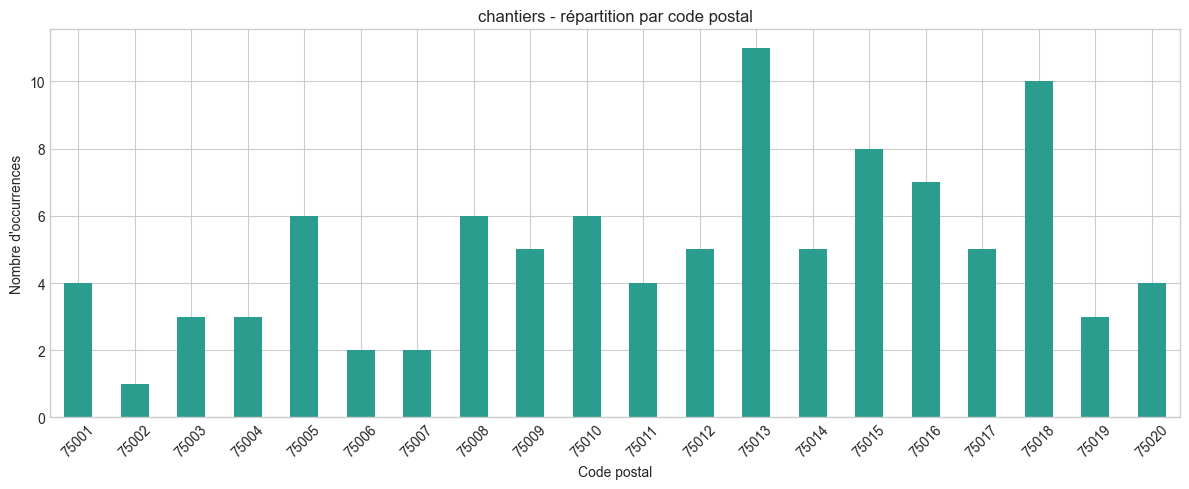

### dans_ma_rue - distribution par code postal


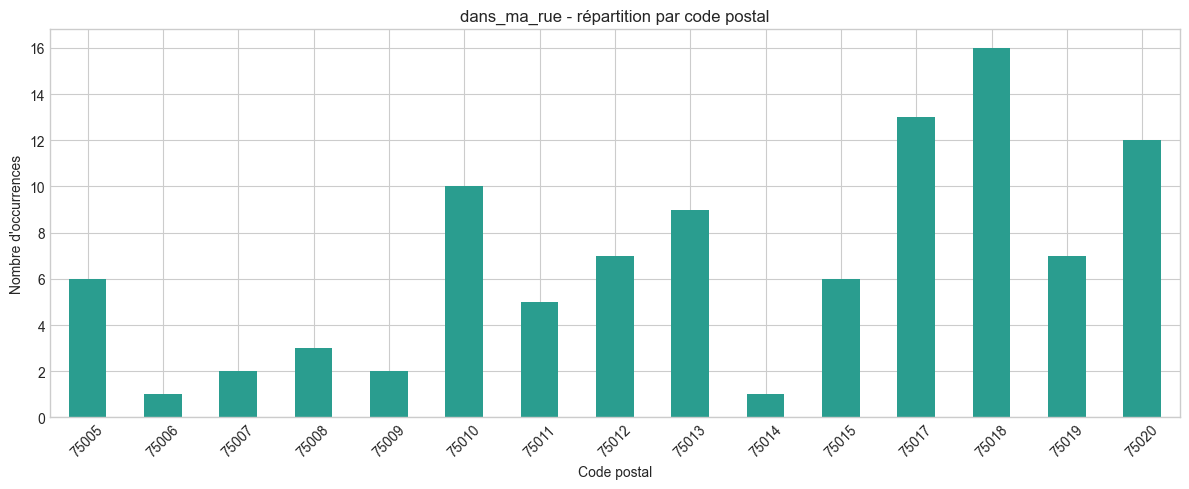

### les-arbres - distribution par code postal


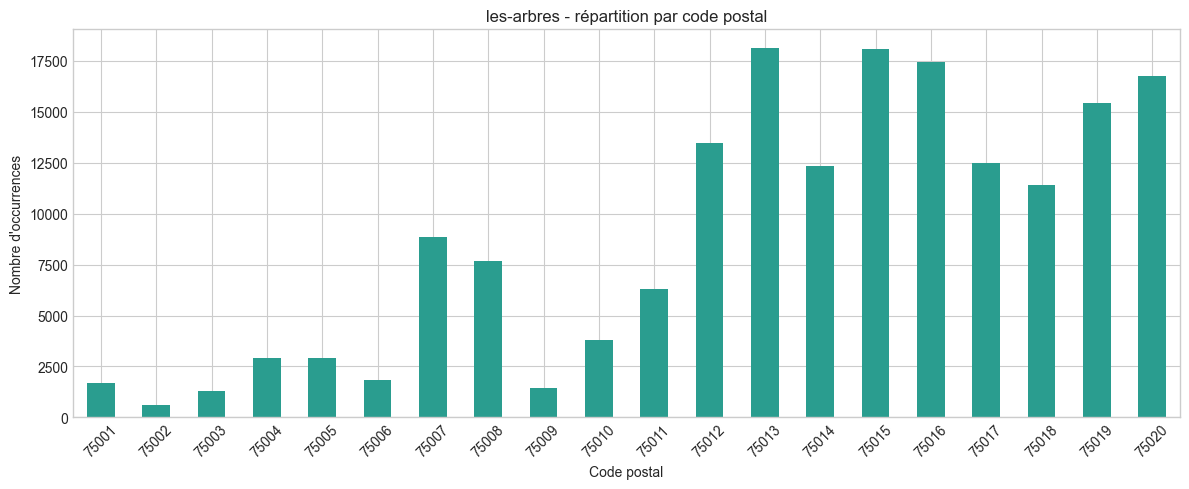

### zones-touristiques-internationales


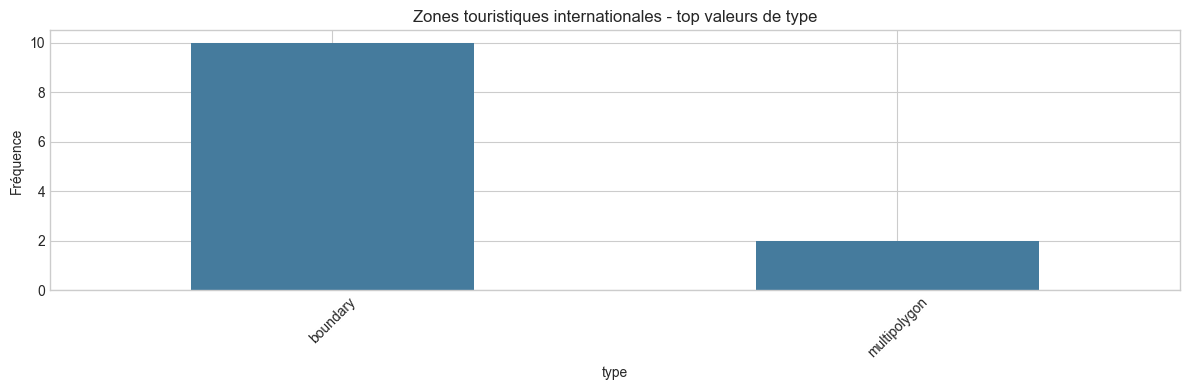

### sanisettesparis


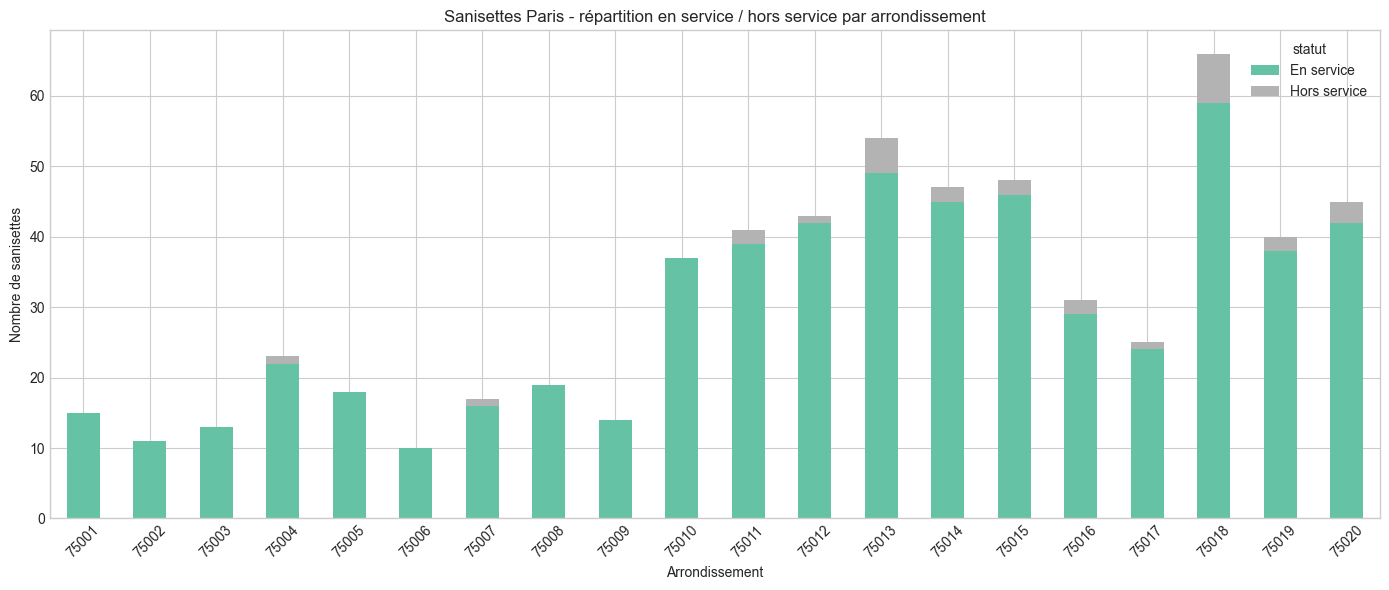

In [32]:
# Visualisations orientées qualité de vie
# 1) Chantiers, incidents et arbres: lecture par code postal
for dataset_name in ['chantiers', 'dans_ma_rue', 'les-arbres']:
    if dataset_name not in datasets:
        continue
    df = datasets[dataset_name]
    print(f'### {dataset_name} - distribution par code postal')
    plot_postal_code_distribution(df, f'{dataset_name} - répartition par code postal')

# 2) Zones touristiques internationales: attractivité et périmètre
if 'zones-touristiques-internationales' in datasets:
    df = datasets['zones-touristiques-internationales']
    print('### zones-touristiques-internationales')
    plot_top_categories(df, ['type'], 'Zones touristiques internationales')

# 3) Sanisettes: répartition service / hors service par arrondissement
if 'sanisettesparis' in datasets:
    df = datasets['sanisettesparis']
    print('### sanisettesparis')

    if {'statut', 'arrondissement'}.issubset(df.columns):
        sanisettes_view = df[['arrondissement', 'statut']].copy()
        sanisettes_view['statut'] = sanisettes_view['statut'].astype(str).str.strip().str.lower()
        sanisettes_view['statut'] = sanisettes_view['statut'].replace({
            'en service': 'En service',
            'hors service': 'Hors service',
            'service': 'En service',
            'hors-service': 'Hors service',
            'hs': 'Hors service',
            'actif': 'En service',
            'inactif': 'Hors service'
        })
        sanisettes_view['statut'] = sanisettes_view['statut'].where(
            sanisettes_view['statut'].isin(['En service', 'Hors service']),
            sanisettes_view['statut'].str.title()
        )

        pivot = pd.crosstab(sanisettes_view['arrondissement'].astype(str), sanisettes_view['statut'])
        preferred_order = [col for col in ['En service', 'Hors service'] if col in pivot.columns]
        remaining_order = [col for col in pivot.columns if col not in preferred_order]
        pivot = pivot[preferred_order + remaining_order]
        pivot = pivot.sort_index()

        ax = pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set2')
        ax.set_title('Sanisettes Paris - répartition en service / hors service par arrondissement')
        ax.set_xlabel('Arrondissement')
        ax.set_ylabel('Nombre de sanisettes')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('Colonnes statut et/ou arrondissement manquantes pour les sanisettes.')